In [1]:
%pip install pyspark matplotlib pandas ipykernel

Note: you may need to restart the kernel to use updated packages.


### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [2]:
import os
import sys

os.environ["JAVA_HOME"] = r"C:\Program Files\Microsoft\jdk-17.0.19.10-hotspot"
os.environ["HADOOP_HOME"] = r"C:\hadoop"

os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql.functions import broadcast

import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Lab5_Chicago_Crimes")
    .master("local[1]")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.python.worker.reuse", "false")
    .config("spark.network.timeout", "600s")
    .config("spark.executor.heartbeatInterval", "60s")
    .getOrCreate()
)

spark

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [3]:
spark = (
    SparkSession.builder
    .appName("Lab5_Chicago_Crimes")
    .master("local[2]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [4]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("chicago_crimes_sample.csv")
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: integer (nullable = true)
 |-- y_coordinate: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)

+-------------+--------------+-------------------+---------------------+----+------------+-

**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [5]:
df.show()

+-------------+----------------+-------------------+--------------------+----+-------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|           id|     case_number|               date|               block|iucr| primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|
+-------------+----------------+-------------------+--------------------+----+-------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|     14193193|        JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...|0820|        THEFT|      $500 AND UNDER|              STREET| false|   false| 811|  

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [6]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

{"ts": "2026-05-29 18:19:40.600", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `vehicle_brand` cannot be resolved. Did you mean one of the following? [`beat`, `description`, `fbi_code`, `iucr`, `location`]. SQLSTATE: 42703", "context": {"file": "line 1 in cell [7]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o53.filter.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `vehicle_brand` cannot be resolved. Did you mean one of the following? [`beat`, `description`, `fbi_code`, `iucr`, `location`]. SQLSTATE: 42703;\n'Filter '`=`('vehicle_brand, Volvo)\n+- Relation [id#17,case_number#18,date#19,block#20,iucr#21,primary_type#22,description#23,location_description#24,arrest#25,domestic#2

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `vehicle_brand` cannot be resolved. Did you mean one of the following? [`beat`, `description`, `fbi_code`, `iucr`, `location`]. SQLSTATE: 42703;
'Filter '`=`('vehicle_brand, Volvo)
+- Relation [id#17,case_number#18,date#19,block#20,iucr#21,primary_type#22,description#23,location_description#24,arrest#25,domestic#26,beat#27,district#28,ward#29,community_area#30,fbi_code#31,x_coordinate#32,y_coordinate#33,year#34,updated_on#35,latitude#36,longitude#37,location#38] csv


In [7]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

{"ts": "2026-05-29 18:19:52.403", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `price` cannot be resolved. Did you mean one of the following? [`id`, `date`, `iucr`, `beat`, `block`]. SQLSTATE: 42703", "context": {"file": "line 2 in cell [8]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o53.withColumn.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `price` cannot be resolved. Did you mean one of the following? [`id`, `date`, `iucr`, `beat`, `block`]. SQLSTATE: 42703;\n'Project [id#17, case_number#18, date#19, block#20, iucr#21, primary_type#22, description#23, location_description#24, arrest#25, domestic#26, beat#27, district#28, ward#29, community_area#30, fbi_code#31, x_coordin

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `price` cannot be resolved. Did you mean one of the following? [`id`, `date`, `iucr`, `beat`, `block`]. SQLSTATE: 42703;
'Project [id#17, case_number#18, date#19, block#20, iucr#21, primary_type#22, description#23, location_description#24, arrest#25, domestic#26, beat#27, district#28, ward#29, community_area#30, fbi_code#31, x_coordinate#32, y_coordinate#33, year#34, updated_on#35, latitude#36, longitude#37, location#38, cast('regexp_replace('price, [^\d], ) as double) AS price_num#218]
+- Relation [id#17,case_number#18,date#19,block#20,iucr#21,primary_type#22,description#23,location_description#24,arrest#25,domestic#26,beat#27,district#28,ward#29,community_area#30,fbi_code#31,x_coordinate#32,y_coordinate#33,year#34,updated_on#35,latitude#36,longitude#37,location#38] csv


In [ ]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

NameError: name 'df' is not defined

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [ ]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

NameError: name 'df' is not defined

In [ ]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [ ]:
df.createOrReplaceTempView("cars")

In [ ]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [ ]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [ ]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [ ]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


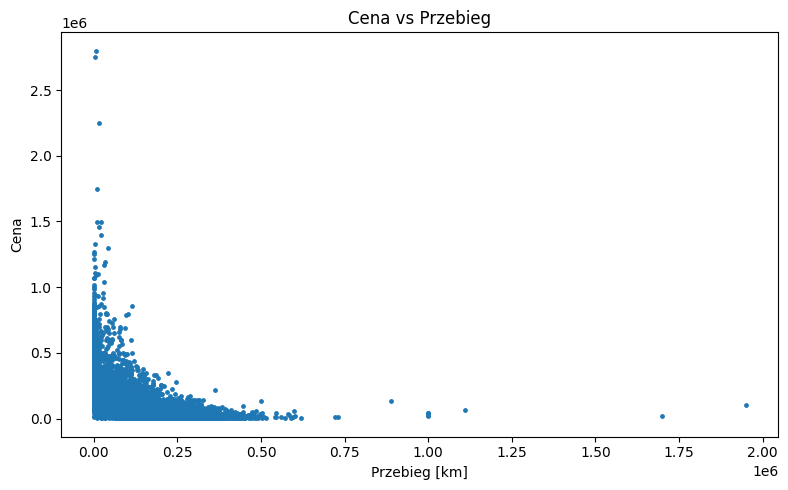

In [ ]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [6]:
import os
import sys

os.environ["JAVA_HOME"] = r"C:\Program Files\Microsoft\jdk-17.0.19.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql.functions import broadcast

import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Lab5_Chicago_Crimes")
    .master("local[1]")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.python.worker.reuse", "false")
    .config("spark.network.timeout", "600s")
    .config("spark.executor.heartbeatInterval", "60s")
    .getOrCreate()
)

spark

In [7]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("chicago_crimes_sample.csv")
)

df.printSchema()
df.show(5, truncate=False)

print("Liczba rekordów:", df.count())
print("Liczba kolumn:", len(df.columns))

df.select(
    "id",
    "case_number",
    "date",
    "primary_type",
    "description",
    "location_description",
    "arrest",
    "domestic",
    "year"
).show(10, truncate=False)

missing_values = df.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]
)

missing_values.show(truncate=False)

root
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: integer (nullable = true)
 |-- y_coordinate: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)

+-------------+--------------+-------------------+---------------------+----+------------+-

In [8]:
df_clean = df.dropDuplicates()

df_clean = (
    df_clean
    .withColumn("date_ts", F.to_timestamp("date"))
    .withColumn("updated_on_ts", F.to_timestamp("updated_on"))
)

df_clean = (
    df_clean
    .filter(F.col("date_ts").isNotNull())
    .filter(F.col("primary_type").isNotNull())
    .filter(F.col("location_description").isNotNull())
    .filter(F.col("year").isNotNull())
)

df_clean = df_clean.filter(
    (F.col("year") >= 2000) &
    (F.col("year") <= 2030)
)

df_clean = (
    df_clean
    .withColumn("crime_year", F.year("date_ts"))
    .withColumn("crime_month", F.month("date_ts"))
    .withColumn("crime_day", F.dayofmonth("date_ts"))
    .withColumn("crime_hour", F.hour("date_ts"))
)

def classify_time_of_day(hour):
    if hour is None:
        return "unknown"
    if 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 18:
        return "day"
    elif 18 <= hour < 22:
        return "evening"
    else:
        return "night"

time_of_day_udf = F.udf(classify_time_of_day, StringType())

df_clean = df_clean.withColumn(
    "time_of_day",
    time_of_day_udf(F.col("crime_hour"))
)

df_clean.cache()

print("Liczba rekordów po czyszczeniu:", df_clean.count())

df_clean.select(
    "date",
    "date_ts",
    "primary_type",
    "location_description",
    "crime_year",
    "crime_month",
    "crime_hour",
    "time_of_day"
).show(10, truncate=False)

Liczba rekordów po czyszczeniu: 49803
+-------------------+-------------------+----------------------+---------------------+----------+-----------+----------+-----------+
|date               |date_ts            |primary_type          |location_description |crime_year|crime_month|crime_hour|time_of_day|
+-------------------+-------------------+----------------------+---------------------+----------+-----------+----------+-----------+
|2026-05-07 00:00:00|2026-05-07 00:00:00|THEFT                 |STREET               |2026      |5          |0         |night      |
|2026-05-07 00:00:00|2026-05-07 00:00:00|ASSAULT               |STREET               |2026      |5          |0         |night      |
|2026-05-07 00:00:00|2026-05-07 00:00:00|THEFT                 |MOVIE HOUSE / THEATER|2026      |5          |0         |night      |
|2026-05-07 00:00:00|2026-05-07 00:00:00|BATTERY               |STREET               |2026      |5          |0         |night      |
|2026-05-07 00:00:00|2026-05-07

In [9]:
severity_data = [
    ("HOMICIDE", "high"),
    ("CRIMINAL SEXUAL ASSAULT", "high"),
    ("ROBBERY", "high"),
    ("ASSAULT", "medium"),
    ("BATTERY", "medium"),
    ("BURGLARY", "medium"),
    ("MOTOR VEHICLE THEFT", "medium"),
    ("NARCOTICS", "medium"),
    ("THEFT", "low"),
    ("CRIMINAL DAMAGE", "low"),
    ("DECEPTIVE PRACTICE", "low")
]

severity_df = spark.createDataFrame(
    severity_data,
    ["primary_type", "severity_level"]
)

df_joined = (
    df_clean
    .join(broadcast(severity_df), on="primary_type", how="left")
    .withColumn(
        "severity_level",
        F.coalesce(F.col("severity_level"), F.lit("other"))
    )
)

df_joined.select(
    "primary_type",
    "severity_level",
    "description",
    "location_description"
).show(20, truncate=False)

df_joined.explain(True)

+----------------------+--------------+----------------------------------------------+---------------------+
|primary_type          |severity_level|description                                   |location_description |
+----------------------+--------------+----------------------------------------------+---------------------+
|THEFT                 |low           |$500 AND UNDER                                |STREET               |
|ASSAULT               |medium        |AGGRAVATED - KNIFE / CUTTING INSTRUMENT       |STREET               |
|THEFT                 |low           |POCKET-PICKING                                |MOVIE HOUSE / THEATER|
|BATTERY               |medium        |SIMPLE                                        |STREET               |
|THEFT                 |low           |$500 AND UNDER                                |STREET               |
|CRIMINAL DAMAGE       |low           |TO VEHICLE                                    |APARTMENT            |
|CRIMINAL DAMAGE   

In [11]:
# Przygotowanie danych do zapisu partycjonowanego po roku
df_output = df_joined.repartition("crime_year")

print("Liczba partycji:", df_output.rdd.getNumPartitions())

# Kod wymaganego zapisu do Parquet z partycjonowaniem po roku.
# W lokalnym środowisku Windows zapis Parquet może wymagać poprawnej konfiguracji Hadoop/winutils.exe.
# Dlatego blok zapisu zostaje pokazany jako część rozwiązania, ale dalsza analiza korzysta z df_output.

# (
#     df_output.write
#     .mode("overwrite")
#     .partitionBy("crime_year")
#     .parquet("output/chicago_crimes_cleaned_parquet")
# )

df_parquet = df_output

df_parquet.printSchema()
df_parquet.show(5, truncate=False)

Liczba partycji: 1
root
 |-- primary_type: string (nullable = true)
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: integer (nullable = true)
 |-- y_coordinate: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)
 |-- date_ts: timestamp (nullable = true)
 |-- updated_on_ts: timestamp (

In [ ]:
#
#Ze względu na lokalne ograniczenia środowiska Windows/Hadoop zapis do Parquet może wymagać dodatkowej konfiguracji `HADOOP_HOME` oraz `winutils.exe`. W rozwiązaniu pokazano kod zapisu do Parquet z partycjonowaniem po roku, a dalsza analiza korzysta z przygotowanego DataFrame `df_output`.

In [12]:
crime_by_type = (
    df_parquet
    .groupBy("primary_type")
    .agg(F.count("*").alias("crime_count"))
    .orderBy(F.desc("crime_count"))
)

crime_by_location = (
    df_parquet
    .groupBy("location_description")
    .agg(F.count("*").alias("crime_count"))
    .orderBy(F.desc("crime_count"))
)

crime_by_year = (
    df_parquet
    .groupBy("crime_year")
    .agg(F.count("*").alias("crime_count"))
    .orderBy("crime_year")
)

crime_by_time_of_day = (
    df_parquet
    .groupBy("time_of_day")
    .agg(F.count("*").alias("crime_count"))
    .orderBy(F.desc("crime_count"))
)

crime_by_month = (
    df_parquet
    .groupBy("crime_month")
    .agg(F.count("*").alias("crime_count"))
    .orderBy("crime_month")
)

print("Przestępstwa według typu:")
crime_by_type.show(20, truncate=False)
crime_by_type.explain(True)

print("Przestępstwa według lokalizacji:")
crime_by_location.show(20, truncate=False)
crime_by_location.explain(True)

print("Przestępstwa według roku:")
crime_by_year.show(truncate=False)
crime_by_year.explain(True)

print("Przestępstwa według pory dnia:")
crime_by_time_of_day.show(truncate=False)
crime_by_time_of_day.explain(True)

print("Przestępstwa według miesiąca:")
crime_by_month.show(truncate=False)
crime_by_month.explain(True)

Przestępstwa według typu:
+--------------------------------+-----------+
|primary_type                    |crime_count|
+--------------------------------+-----------+
|THEFT                           |10920      |
|BATTERY                         |9253       |
|CRIMINAL DAMAGE                 |5497       |
|ASSAULT                         |4564       |
|MOTOR VEHICLE THEFT             |3886       |
|OTHER OFFENSE                   |3459       |
|BURGLARY                        |3163       |
|DECEPTIVE PRACTICE              |2486       |
|NARCOTICS                       |1455       |
|CRIMINAL TRESPASS               |1193       |
|WEAPONS VIOLATION               |1022       |
|ROBBERY                         |916        |
|OFFENSE INVOLVING CHILDREN      |368        |
|CRIMINAL SEXUAL ASSAULT         |331        |
|SEX OFFENSE                     |306        |
|PUBLIC PEACE VIOLATION          |256        |
|INTERFERENCE WITH PUBLIC OFFICER|205        |
|STALKING                        |

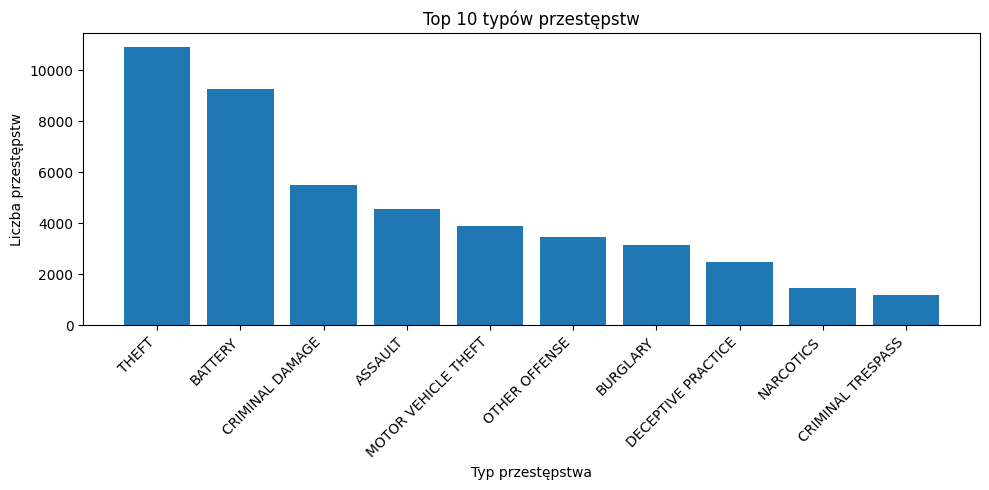

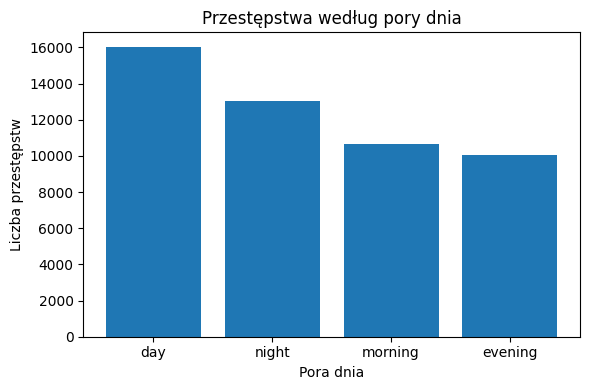

In [13]:
pdf_type = crime_by_type.limit(10).toPandas()

plt.figure(figsize=(10, 5))
plt.bar(pdf_type["primary_type"], pdf_type["crime_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 typów przestępstw")
plt.xlabel("Typ przestępstwa")
plt.ylabel("Liczba przestępstw")
plt.tight_layout()
plt.show()

pdf_time = crime_by_time_of_day.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(pdf_time["time_of_day"], pdf_time["crime_count"])
plt.title("Przestępstwa według pory dnia")
plt.xlabel("Pora dnia")
plt.ylabel("Liczba przestępstw")
plt.tight_layout()
plt.show()